## 2025 Out-of-Sample Model Validation
### XGBoost vs SARIMA — Test Period: January–December 2025
**Model trained on:** 2014–2024 &nbsp;|&nbsp; **Validation period:** 2025

This notebook loads pre-computed predictions from the XGBoost and SARIMA notebooks and evaluates both models on fully unseen 2025 data.

### Setup & Imports


In [37]:
# Add project root to path
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"✓ Project root: {project_root}")

✓ Project root: /home/brenda/final year project/PharmacyForecastingSystem


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✓ All packages imported successfully")

✓ All packages imported successfully


## 1. Load Pre-Computed Predictions (2025 Test Period)


In [39]:
data_dir = Path(project_root) / 'data' / 'results'

# ── Load XGBoost predictions (2025) ──────────────────────────────────────────
xgb_pred_path = data_dir / 'xgboost' / 'xgboost_predictions.csv'
xgb_df = pd.read_csv(xgb_pred_path, parse_dates=['week_start_date'])
xgb_df = xgb_df[xgb_df['week_start_date'].dt.year == 2025].copy()
xgb_df = xgb_df.sort_values(['drug_name', 'week_start_date']).reset_index(drop=True)

# ── Load SARIMA predictions (filter to 2025 for apples-to-apples comparison) ─
sar_pred_path = data_dir / 'sarima' / 'sarima_predictions.csv'
sar_df = pd.read_csv(sar_pred_path, parse_dates=['week_start_date'])
sar_df = sar_df[sar_df['week_start_date'].dt.year == 2025].copy()
sar_df = sar_df.sort_values(['drug_name', 'week_start_date']).reset_index(drop=True)

# ── Load per-drug results (already computed in training notebooks) ─────────────
xgb_results = pd.read_csv(data_dir / 'xgboost' / 'xgboost_results.csv')
sar_results  = pd.read_csv(data_dir / 'sarima'  / 'sarima_results.csv')

# ── Load overall XGBoost validation metrics ────────────────────────────────────
with open(data_dir / 'xgboost' / 'validation_metrics.json') as f:
    val_metrics = json.load(f)

print('=' * 65)
print('PREDICTIONS LOADED')
print('=' * 65)
print(f"\nXGBoost predictions  : {len(xgb_df):,} rows")
print(f"  Date range         : {xgb_df['week_start_date'].min().date()}  →  {xgb_df['week_start_date'].max().date()}")
print(f"  Drugs              : {sorted(xgb_df['drug_name'].unique())}")

print(f"\nSARIMA predictions   : {len(sar_df):,} rows")
print(f"  Date range         : {sar_df['week_start_date'].min().date()}  →  {sar_df['week_start_date'].max().date()}")
print(f"  Drugs              : {sorted(sar_df['drug_name'].unique())}")

print(f"\nXGBoost train period : {val_metrics['train_period']}")
print(f"XGBoost val period   : {val_metrics['val_period']}")
print(f"\n✓ All prediction files loaded successfully")


PREDICTIONS LOADED

XGBoost predictions  : 408 rows
  Date range         : 2025-01-06  →  2025-12-22
  Drugs              : ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

SARIMA predictions   : 408 rows
  Date range         : 2025-01-06  →  2025-12-22
  Drugs              : ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

XGBoost train period : 2014-2024
XGBoost val period   : 2025

✓ All prediction files loaded successfully


## 2. Data Overview

| Split | Period | Purpose |
|-------|--------|---------|
| Training | 2014–2024 | Both models learned seasonal/trend patterns |
| **Test (this notebook)** | **2025** | **Fully unseen out-of-sample evaluation** |

Both XGBoost and SARIMA predictions were computed in their respective training notebooks and saved to CSV. This notebook loads those files and performs a head-to-head evaluation.


In [40]:
# ── Merge both predictions on the same (drug, week) keys ─────────────────────
# Use XGBoost actual as ground truth (both files share the same actuals for 2025)
merged = xgb_df.merge(
    sar_df[['drug_name', 'week_start_date', 'sarima_pred']],
    on=['drug_name', 'week_start_date'],
    how='inner'
).copy()
merged.rename(columns={'actual': 'total_quantity'}, inplace=True)
merged['quarter'] = merged['week_start_date'].dt.quarter

# Convenience aliases used throughout the notebook
TARGET     = 'total_quantity'
XGB_PRED   = 'xgb_pred'
SAR_PRED   = 'sarima_pred'

print('=' * 65)
print('2025 TEST DATASET OVERVIEW')
print('=' * 65)
print(f"  Rows (drug × week) : {len(merged):,}")
print(f"  Date range         : {merged['week_start_date'].min().date()}  →  {merged['week_start_date'].max().date()}")
print(f"  Unique weeks       : {merged['week_start_date'].nunique()}")
print(f"  Drugs evaluated    : {merged['drug_name'].nunique()}  →  {sorted(merged['drug_name'].unique())}")
print()
print(f"  Actual qty range   : {merged[TARGET].min():.0f}  –  {merged[TARGET].max():.0f}")
print(f"  XGBoost pred range : {merged[XGB_PRED].min():.2f}  –  {merged[XGB_PRED].max():.2f}")
print(f"  SARIMA  pred range : {merged[SAR_PRED].min():.2f}  –  {merged[SAR_PRED].max():.2f}")
print(f"\n✓ Dataset ready for evaluation (n={len(merged):,} records)")


2025 TEST DATASET OVERVIEW
  Rows (drug × week) : 408
  Date range         : 2025-01-06  →  2025-12-22
  Unique weeks       : 51
  Drugs evaluated    : 8  →  ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

  Actual qty range   : 0  –  380
  XGBoost pred range : 5.47  –  367.46
  SARIMA  pred range : 0.00  –  1574.62

✓ Dataset ready for evaluation (n=408 records)


## 3. Overall Performance Metrics

In [41]:
def calc_metrics(y_true, y_pred, label='Model'):
    """Return a dict of forecasting metrics for a single model."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mask = y_true > 5
    mape  = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100 if y_true.sum() > 0 else np.nan
    return {
        'Model': label,
        'MAE': round(float(mae), 2),
        'RMSE': round(float(rmse), 2),
        'MAPE': round(float(mape), 2) if not np.isnan(mape) else None,
        'WMAPE': round(float(wmape), 2) if not np.isnan(wmape) else None,
        'R2': round(float(r2), 4),
    }


# ── Compute overall 2025 metrics for each model ───────────────────────────────
metrics_xgb = calc_metrics(merged[TARGET], merged[XGB_PRED], 'XGBoost (2025 test)')
metrics_sar = calc_metrics(merged[TARGET], merged[SAR_PRED], 'SARIMA  (2025 test)')

overall_df = pd.DataFrame([metrics_xgb, metrics_sar]).set_index('Model')

print('=' * 65)
print('OVERALL 2025 TEST PERFORMANCE')
print('=' * 65)
display(overall_df)

# Winner per metric
print()
for m in ['MAE', 'RMSE', 'WMAPE']:
    winner = 'XGBoost' if metrics_xgb[m] <= metrics_sar[m] else 'SARIMA'
    print(f"  {m:6s}: {winner} wins  ({metrics_xgb[m]:.2f} vs {metrics_sar[m]:.2f})")
r2_winner = 'XGBoost' if metrics_xgb['R2'] >= metrics_sar['R2'] else 'SARIMA'
print(f"  {'R2':6s}: {r2_winner} wins  ({metrics_xgb['R2']:.4f} vs {metrics_sar['R2']:.4f})")


OVERALL 2025 TEST PERFORMANCE


,MAE,RMSE,MAPE,WMAPE,R2
Model,,,,,
XGBoost (2025 test),14.2900,24.8500,28.5400,25.1100,0.8774
SARIMA (2025 test),68.4300,136.3800,133.4300,120.2000,-2.6930



  MAE   : XGBoost wins  (14.29 vs 68.43)
  RMSE  : XGBoost wins  (24.85 vs 136.38)
  WMAPE : XGBoost wins  (25.11 vs 120.20)
  R2    : XGBoost wins  (0.8774 vs -2.6930)


In [42]:
# ── Side-by-side comparison using saved per-drug results files ────────────────
xgb_res = xgb_results[['Drug', 'Segment', 'MAE', 'RMSE', 'MAPE', 'WMAPE', 'R2']].copy()
xgb_res.columns = ['Drug', 'Segment', 'XGB_MAE', 'XGB_RMSE', 'XGB_MAPE', 'XGB_WMAPE', 'XGB_R2']

sar_res = sar_results[['Drug', 'MAE', 'RMSE', 'MAPE', 'WMAPE', 'R2']].copy()
sar_res.columns = ['Drug', 'SAR_MAE', 'SAR_RMSE', 'SAR_MAPE', 'SAR_WMAPE', 'SAR_R2']

comp = xgb_res.merge(sar_res, on='Drug', how='outer').sort_values('XGB_MAE')

# Who wins per drug?
comp['Better_MAE'] = np.where(comp['XGB_MAE'] <= comp['SAR_MAE'], '✅ XGBoost', '⚠ SARIMA')
comp['MAE_ratio']  = (comp['SAR_MAE'] / comp['XGB_MAE']).round(1)

print('=' * 90)
print('PER-DRUG RESULTS (2025) — XGBoost vs SARIMA')
print('=' * 90)
display(comp[['Drug','Segment','XGB_MAE','SAR_MAE','MAE_ratio','Better_MAE','XGB_R2','SAR_R2']])

xgb_wins = (comp['XGB_MAE'] <= comp['SAR_MAE']).sum()
print(f"\nXGBoost wins on MAE in {xgb_wins}/{len(comp)} drugs")


PER-DRUG RESULTS (2025) — XGBoost vs SARIMA


,Drug,Segment,XGB_MAE,SAR_MAE,MAE_ratio,Better_MAE,XGB_R2,SAR_R2
5,N05C,Low Volume,2.4100,3.6500,1.5000,✅ XGBoost,-0.4496,-2.1505
1,M01AE,Medium Volume,4.8400,49.9500,10.3000,✅ XGBoost,0.1029,-161.7525
2,N02BA,Medium Volume,5.1900,6.4700,1.2000,✅ XGBoost,-0.2160,-1.4634
0,M01AB,Medium Volume,7.9100,44.1800,5.6000,✅ XGBoost,0.0078,-24.6719
7,R06,Medium Volume,8.9500,31.7800,3.6000,✅ XGBoost,0.5772,-3.5765
4,N05B,High Volume,15.1700,148.4700,9.8000,✅ XGBoost,-0.2818,-584.6460
6,R03,High Volume,20.9800,78.0100,3.7000,✅ XGBoost,0.4022,-8.0270
3,N02BE,High Volume,48.8900,104.4200,2.1000,✅ XGBoost,0.4277,-55.4101



XGBoost wins on MAE in 8/8 drugs


## 4. XGBoost Performance Validation

In [43]:
y_actual = merged[TARGET].values
y_xgb    = merged[XGB_PRED].values

# ── Compare stored benchmark metrics with recomputed 2025 metrics ─────────────
stored_mae  = val_metrics['mae']
stored_mape = val_metrics['mape']
stored_r2   = val_metrics['r2']

# Recompute directly from predictions file
mae_2025  = metrics_xgb['MAE']
mape_2025 = metrics_xgb['MAPE']
r2_2025   = metrics_xgb['R2']

bench_df = pd.DataFrame({
    'Stored (val_metrics.json)': [stored_mae,  stored_mape,  stored_r2],
    'Recomputed from CSV':       [mae_2025,     mape_2025,    r2_2025],
}, index=['MAE', 'MAPE (%)', 'R²'])

print('=' * 65)
print('XGBOOST — STORED vs RECOMPUTED 2025 METRICS')
print('=' * 65)
display(bench_df)

MAE_ABS_PASS = 5.0
mae_change   = (mae_2025 - stored_mae) / stored_mae

if mae_2025 <= MAE_ABS_PASS:
    print(f"\n✅ XGBoost PASSED: MAE = {mae_2025:.2f} units/week (threshold ≤ {MAE_ABS_PASS})")
elif abs(mae_change) <= 0.20:
    print(f"\n✅ XGBoost PASSED: MAE change = {mae_change*100:+.1f}% (within 20%)")
elif abs(mae_change) <= 0.50:
    print(f"\n⚠  XGBoost ACCEPTABLE: MAE change = {mae_change*100:+.1f}%")
else:
    print(f"\n❌ XGBoost shows drift: MAE change = {mae_change*100:+.1f}%")


XGBOOST — STORED vs RECOMPUTED 2025 METRICS


,Stored (val_metrics.json),Recomputed from CSV
MAE,14.2900,14.2900
MAPE (%),28.5400,28.5400
R²,0.8774,0.8774



✅ XGBoost PASSED: MAE change = +0.0% (within 20%)


## 5. SARIMA Performance Validation

In [44]:
y_sarima = merged[SAR_PRED].values

# Per-drug SARIMA summary (from saved results file)
print('=' * 65)
print('SARIMA — 2025 PER-DRUG RESULTS')
print('=' * 65)
sar_display = sar_results[['Drug','Segment','MAE','RMSE','MAPE','WMAPE','R2','order','s_order','n_train','n_test']].copy()
display(sar_display)

# Flag drugs where SARIMA is competitive (MAE within 2x of XGBoost)
comp_ratio = comp[['Drug','XGB_MAE','SAR_MAE','MAE_ratio']].copy()
competitive = comp_ratio[comp_ratio['MAE_ratio'] <= 2.0]
struggling  = comp_ratio[comp_ratio['MAE_ratio'] > 2.0]
print(f"\n✅ SARIMA competitive (MAE ≤ 2× XGBoost): {len(competitive)}/{len(comp_ratio)} drugs")
if len(competitive):
    print("  ", list(competitive['Drug']))
print(f"⚠  SARIMA struggling  (MAE > 2× XGBoost): {len(struggling)}/{len(comp_ratio)} drugs")
if len(struggling):
    print("  ", list(struggling['Drug']))


SARIMA — 2025 PER-DRUG RESULTS


,Drug,Segment,MAE,RMSE,MAPE,WMAPE,R2,order,s_order,n_train,n_test
0,M01AB,Medium Volume,44.1800,45.7400,90.1100,90.7800,-24.6719,"(1, 0, 1)","(0, 1, 1, 52)",102,104
1,M01AE,Medium Volume,49.9500,77.1400,158.8400,159.2100,-161.7525,"(1, 0, 1)","(0, 1, 1, 52)",77,104
2,N02BA,Medium Volume,6.4700,8.4000,100.0000,100.0000,-1.4634,"(0, 0, 0)","(0, 1, 1, 52)",142,104
3,N02BE,High Volume,104.4200,106.0200,95.1600,95.2700,-55.4101,"(2, 0, 2)","(0, 1, 1, 52)",522,104
4,N05B,High Volume,148.4700,376.1300,393.6700,434.3300,-584.6460,"(1, 0, 1)","(0, 1, 1, 52)",72,104
5,N05C,Low Volume,3.6500,4.4400,94.1100,91.8800,-2.1505,"(1, 0, 1)","(0, 1, 1, 52)",271,104
6,R03,High Volume,78.0100,82.7300,100.0000,100.0000,-8.0270,"(0, 0, 0)","(0, 1, 1, 52)",212,104
7,R06,Medium Volume,31.7800,35.9300,95.4800,96.3600,-3.5765,"(2, 0, 0)","(0, 1, 0, 52)",252,104



✅ SARIMA competitive (MAE ≤ 2× XGBoost): 2/8 drugs
   ['N05C', 'N02BA']
⚠  SARIMA struggling  (MAE > 2× XGBoost): 6/8 drugs
   ['M01AE', 'M01AB', 'R06', 'N05B', 'R03', 'N02BE']


## 6. Per-Drug Performance Analysis

In [45]:
per_drug_rows = []
for drug in sorted(merged['drug_name'].unique()):
    ddf = merged[merged['drug_name'] == drug]
    seg = xgb_results.set_index('Drug')['Segment'].get(drug, 'Unknown')
    mx = calc_metrics(ddf[TARGET], ddf[XGB_PRED], drug)
    ms = calc_metrics(ddf[TARGET], ddf[SAR_PRED], drug)
    per_drug_rows.append({
        'Drug':       drug,
        'Segment':    seg,
        'n_weeks':    len(ddf),
        'mean_actual': ddf[TARGET].mean().round(1),
        'XGB_MAE':    mx['MAE'],
        'SAR_MAE':    ms['MAE'],
        'XGB_WMAPE':  mx['WMAPE'],
        'SAR_WMAPE':  ms['WMAPE'],
        'XGB_R2':     mx['R2'],
        'SAR_R2':     ms['R2'],
        'Winner':     '✅ XGBoost' if mx['MAE'] <= ms['MAE'] else '⚠ SARIMA',
    })

per_drug_df = pd.DataFrame(per_drug_rows).sort_values('XGB_MAE')

print('=' * 75)
print('PER-DRUG RECOMPUTED METRICS — 2025 TEST PERIOD')
print('=' * 75)
display(per_drug_df)

xgb_wins_cnt = (per_drug_df['Winner'] == '✅ XGBoost').sum()
print(f"\n📊 XGBoost beats SARIMA on MAE: {xgb_wins_cnt}/{len(per_drug_df)} drugs")

best  = per_drug_df.loc[per_drug_df['XGB_MAE'].idxmin()]
worst = per_drug_df.loc[per_drug_df['XGB_MAE'].idxmax()]
print(f"\n  Best XGBoost performer : {best['Drug']} (MAE {best['XGB_MAE']:.2f})")
print(f"  Worst XGBoost performer: {worst['Drug']} (MAE {worst['XGB_MAE']:.2f})")


PER-DRUG RECOMPUTED METRICS — 2025 TEST PERIOD


,Drug,Segment,n_weeks,mean_actual,XGB_MAE,SAR_MAE,XGB_WMAPE,SAR_WMAPE,XGB_R2,SAR_R2,Winner
5,N05C,Low Volume,51,4.3000,2.4100,4.2800,56.3500,100.0200,-0.4496,-2.9029,✅ XGBoost
1,M01AE,Medium Volume,51,31.4000,4.8400,35.1900,15.4100,111.9600,0.1029,-94.4161,✅ XGBoost
2,N02BA,Medium Volume,51,5.9000,5.1900,5.9200,87.6700,100.0000,-0.2160,-1.0986,✅ XGBoost
0,M01AB,Medium Volume,51,49.9000,7.9100,49.1000,15.8400,98.3500,0.0078,-24.5161,✅ XGBoost
7,R06,Medium Volume,51,34.6000,8.9500,33.9700,25.8800,98.2700,0.5772,-3.9163,✅ XGBoost
4,N05B,High Volume,51,33.4000,15.1700,123.0700,45.4100,368.3300,-0.2818,-307.7421,✅ XGBoost
6,R03,High Volume,51,83.1000,20.9800,83.1000,25.2400,100.0000,0.4022,-5.7450,✅ XGBoost
3,N02BE,High Volume,51,212.8000,48.8900,212.7800,22.9800,100.0000,0.4277,-7.2436,✅ XGBoost



📊 XGBoost beats SARIMA on MAE: 8/8 drugs

  Best XGBoost performer : N05C (MAE 2.41)
  Worst XGBoost performer: N02BE (MAE 48.89)


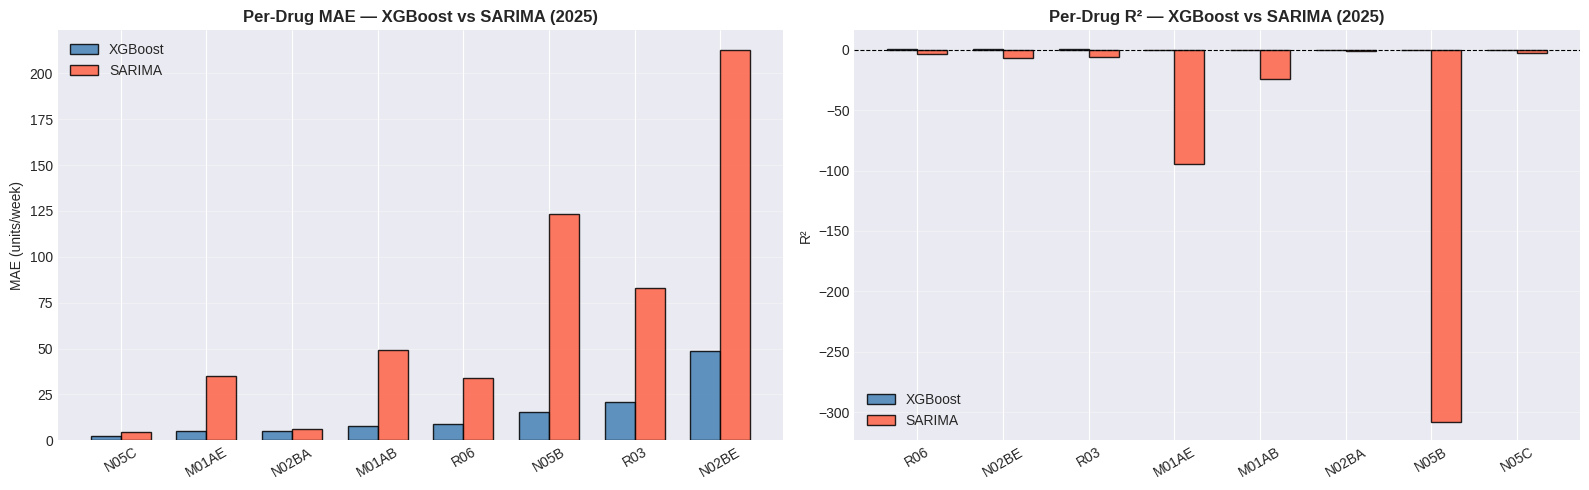

✓ Per-drug comparison charts generated


In [46]:
# ── Side-by-side MAE bar chart per drug ──────────────────────────────────────
sorted_drugs = per_drug_df.sort_values('XGB_MAE')['Drug'].tolist()
x = np.arange(len(sorted_drugs))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Per-drug MAE
ax = axes[0]
bars_xgb = ax.bar(x - width/2, per_drug_df.set_index('Drug').loc[sorted_drugs, 'XGB_MAE'],
                  width, label='XGBoost', color='steelblue', edgecolor='black', alpha=0.85)
bars_sar = ax.bar(x + width/2, per_drug_df.set_index('Drug').loc[sorted_drugs, 'SAR_MAE'],
                  width, label='SARIMA',  color='tomato',    edgecolor='black', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(sorted_drugs, rotation=30)
ax.set_ylabel('MAE (units/week)')
ax.set_title('Per-Drug MAE — XGBoost vs SARIMA (2025)', fontweight='bold')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# Chart 2: Per-drug R²
sorted_r2 = per_drug_df.sort_values('XGB_R2', ascending=False)['Drug'].tolist()
ax2 = axes[1]
ax2.bar(x - width/2, per_drug_df.set_index('Drug').loc[sorted_r2, 'XGB_R2'],
        width, label='XGBoost', color='steelblue', edgecolor='black', alpha=0.85)
ax2.bar(x + width/2, per_drug_df.set_index('Drug').loc[sorted_r2, 'SAR_R2'],
        width, label='SARIMA',  color='tomato',    edgecolor='black', alpha=0.85)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xticks(x)
ax2.set_xticklabels(sorted_r2, rotation=30)
ax2.set_ylabel('R²')
ax2.set_title('Per-Drug R² — XGBoost vs SARIMA (2025)', fontweight='bold')
ax2.legend()
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Per-drug comparison charts generated")


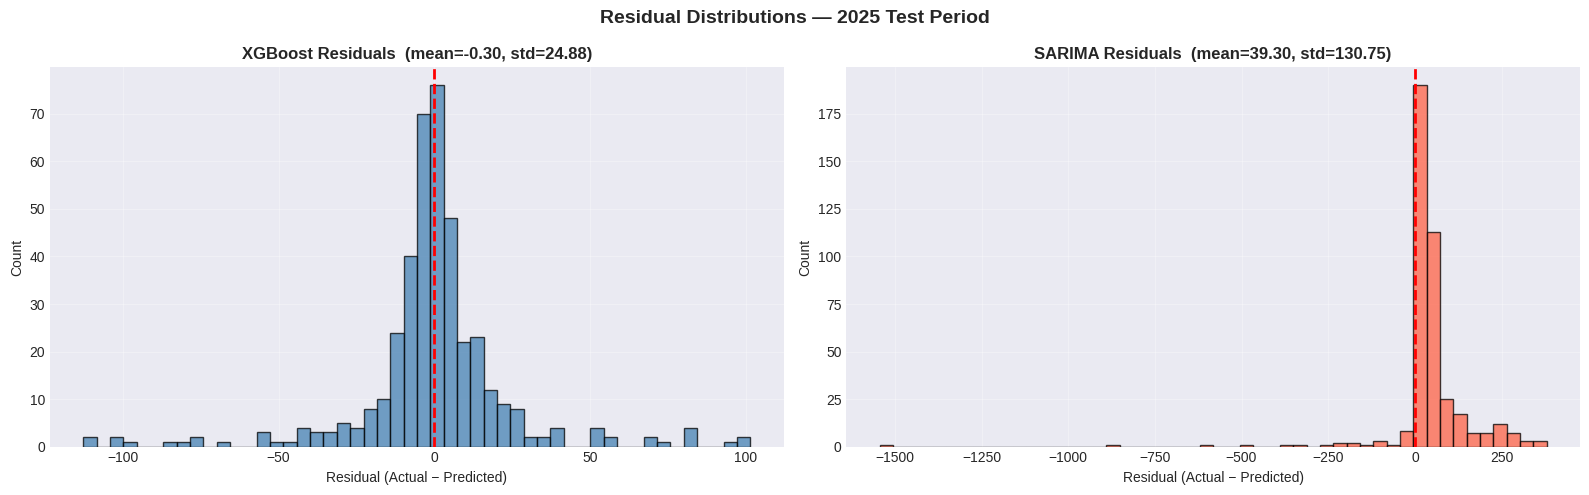

✓ Residual distribution charts generated


In [47]:
# ── Residual analysis — XGBoost ───────────────────────────────────────────────
merged['xgb_error']    = merged[TARGET] - merged[XGB_PRED]
merged['sarima_error'] = merged[TARGET] - merged[SAR_PRED]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# XGBoost residuals
axes[0].hist(merged['xgb_error'], bins=50, color='steelblue', edgecolor='black', alpha=0.75)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title(f"XGBoost Residuals  (mean={merged['xgb_error'].mean():.2f}, std={merged['xgb_error'].std():.2f})",
                  fontweight='bold')
axes[0].set_xlabel('Residual (Actual − Predicted)')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

# SARIMA residuals
axes[1].hist(merged['sarima_error'], bins=50, color='tomato', edgecolor='black', alpha=0.75)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title(f"SARIMA Residuals  (mean={merged['sarima_error'].mean():.2f}, std={merged['sarima_error'].std():.2f})",
                  fontweight='bold')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Residual Distributions — 2025 Test Period', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✓ Residual distribution charts generated")


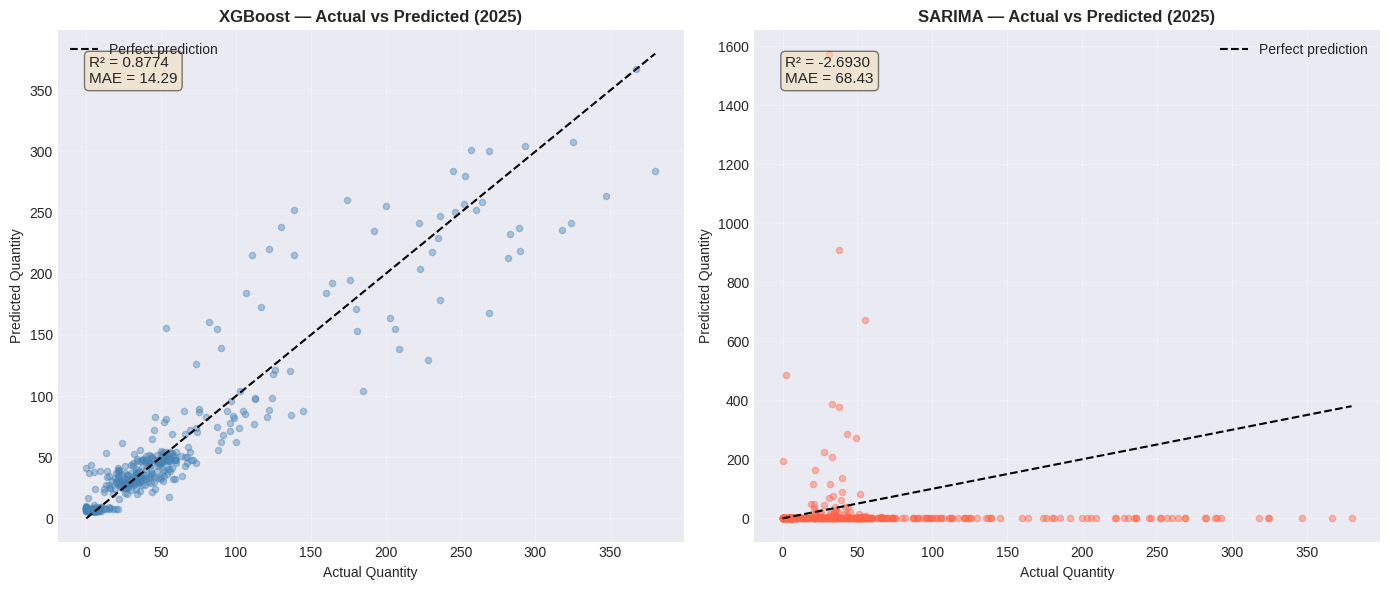

✓ Scatter plots generated


In [48]:
# ── Actual vs Predicted scatter plots ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pred_col, label, color in [
    (axes[0], XGB_PRED, 'XGBoost', 'steelblue'),
    (axes[1], SAR_PRED, 'SARIMA',  'tomato'),
]:
    y_true = merged[TARGET]
    y_pred = merged[pred_col]
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    lo, hi = y_true.min(), y_true.max()
    ax.scatter(y_true, y_pred, alpha=0.4, s=20, color=color)
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Quantity')
    ax.set_ylabel('Predicted Quantity')
    ax.set_title(f'{label} — Actual vs Predicted (2025)', fontweight='bold')
    ax.text(0.05, 0.95, f"R² = {r2:.4f}\nMAE = {mae:.2f}", transform=ax.transAxes,
            fontsize=11, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("✓ Scatter plots generated")


## 7. Quarterly Performance Analysis (2025)


In [49]:
quarterly_rows = []
for q in sorted(merged['quarter'].unique()):
    qdf = merged[merged['quarter'] == q]
    mx  = calc_metrics(qdf[TARGET], qdf[XGB_PRED], f'Q{q} — XGBoost')
    ms  = calc_metrics(qdf[TARGET], qdf[SAR_PRED],  f'Q{q} — SARIMA')
    mx['Quarter'] = q;  mx['Weeks'] = qdf['week_start_date'].nunique()
    ms['Quarter'] = q;  ms['Weeks'] = qdf['week_start_date'].nunique()
    quarterly_rows.extend([mx, ms])

quarterly_df = pd.DataFrame(quarterly_rows)

print('=' * 70)
print('QUARTERLY PERFORMANCE — 2025 TEST PERIOD')
print('=' * 70)
display(quarterly_df[['Model','Quarter','Weeks','MAE','RMSE','WMAPE','R2']])

# MAE drift within XGBoost across quarters
xgb_q = quarterly_df[quarterly_df['Model'].str.contains('XGBoost')].sort_values('Quarter')
mae_q = xgb_q['MAE'].values
if len(mae_q) > 1:
    drift = (mae_q[-1] - mae_q[0]) / mae_q[0] * 100
    trend = '↑ Increasing (model drifts)' if drift > 10 else ('↓ Decreasing (stable/improving)' if drift < -10 else '→ Stable')
    print(f"\nXGBoost Q1→Q4 MAE drift: {drift:+.1f}%  ({trend})")


QUARTERLY PERFORMANCE — 2025 TEST PERIOD


,Model,Quarter,Weeks,MAE,RMSE,WMAPE,R2
0,Q1 — XGBoost,1,13,15.6700,26.8000,25.2200,0.8780
1,Q1 — SARIMA,1,13,87.0700,195.5600,140.1100,-5.4940
2,Q2 — XGBoost,2,13,13.6200,24.3100,26.7000,0.7839
3,Q2 — SARIMA,2,13,57.9000,91.1400,113.5200,-2.0381
4,Q3 — XGBoost,3,13,13.2200,23.4600,26.9300,0.8436
5,Q3 — SARIMA,3,13,61.3800,121.0200,124.9900,-3.1643
6,Q4 — XGBoost,4,12,14.6900,24.6900,22.2000,0.9241
7,Q4 — SARIMA,4,12,67.2600,112.9000,101.6700,-0.5868



XGBoost Q1→Q4 MAE drift: -6.3%  (→ Stable)


## 8. Quarterly MAE Trend Chart


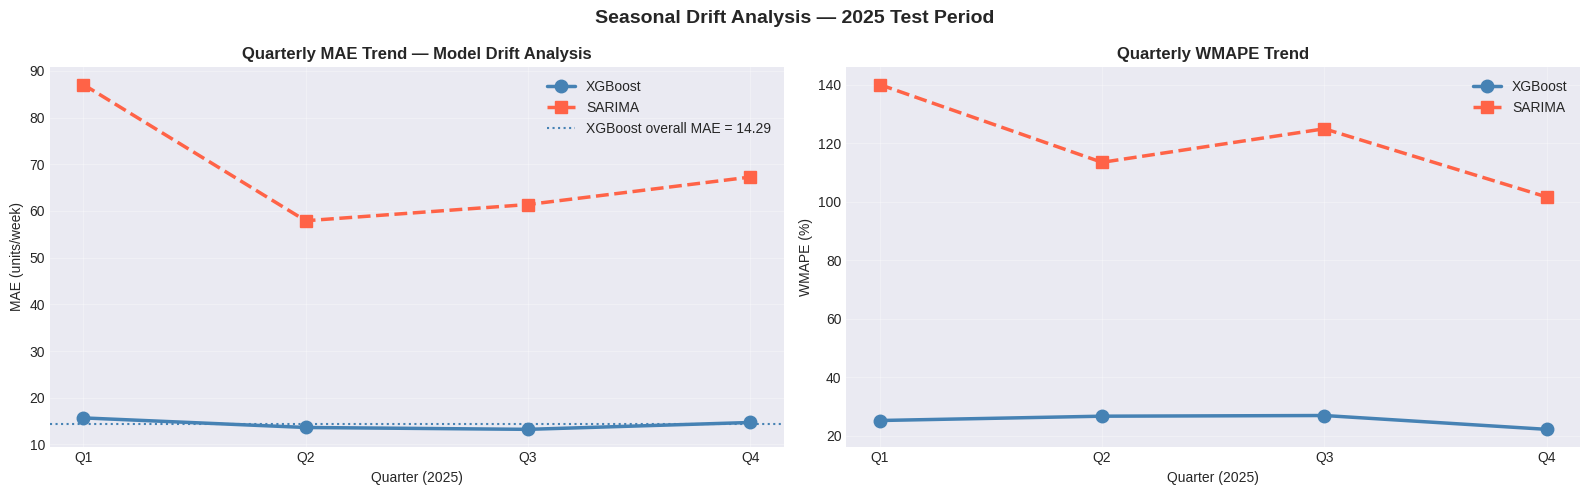

✓ Quarterly trend charts generated


In [50]:
xgb_q  = quarterly_df[quarterly_df['Model'].str.contains('XGBoost')].sort_values('Quarter')
sar_q  = quarterly_df[quarterly_df['Model'].str.contains('SARIMA')].sort_values('Quarter')
labels = [f'Q{q}' for q in xgb_q['Quarter']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Quarterly MAE line
ax = axes[0]
ax.plot(labels, xgb_q['MAE'], marker='o', linewidth=2.5, markersize=9,
        color='steelblue', label='XGBoost')
ax.plot(labels, sar_q['MAE'],  marker='s', linewidth=2.5, markersize=9,
        color='tomato',    label='SARIMA',  linestyle='--')
ax.axhline(metrics_xgb['MAE'], color='steelblue', linestyle=':', linewidth=1.5,
           label=f"XGBoost overall MAE = {metrics_xgb['MAE']:.2f}")
ax.set_xlabel('Quarter (2025)')
ax.set_ylabel('MAE (units/week)')
ax.set_title('Quarterly MAE Trend — Model Drift Analysis', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# Quarterly WMAPE
ax2 = axes[1]
ax2.plot(labels, xgb_q['WMAPE'], marker='o', linewidth=2.5, markersize=9,
         color='steelblue', label='XGBoost')
ax2.plot(labels, sar_q['WMAPE'],  marker='s', linewidth=2.5, markersize=9,
         color='tomato',    label='SARIMA',  linestyle='--')
ax2.set_xlabel('Quarter (2025)')
ax2.set_ylabel('WMAPE (%)')
ax2.set_title('Quarterly WMAPE Trend', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Seasonal Drift Analysis — 2025 Test Period', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✓ Quarterly trend charts generated")


## 9. Per-Drug Time Series: Actual vs Predicted


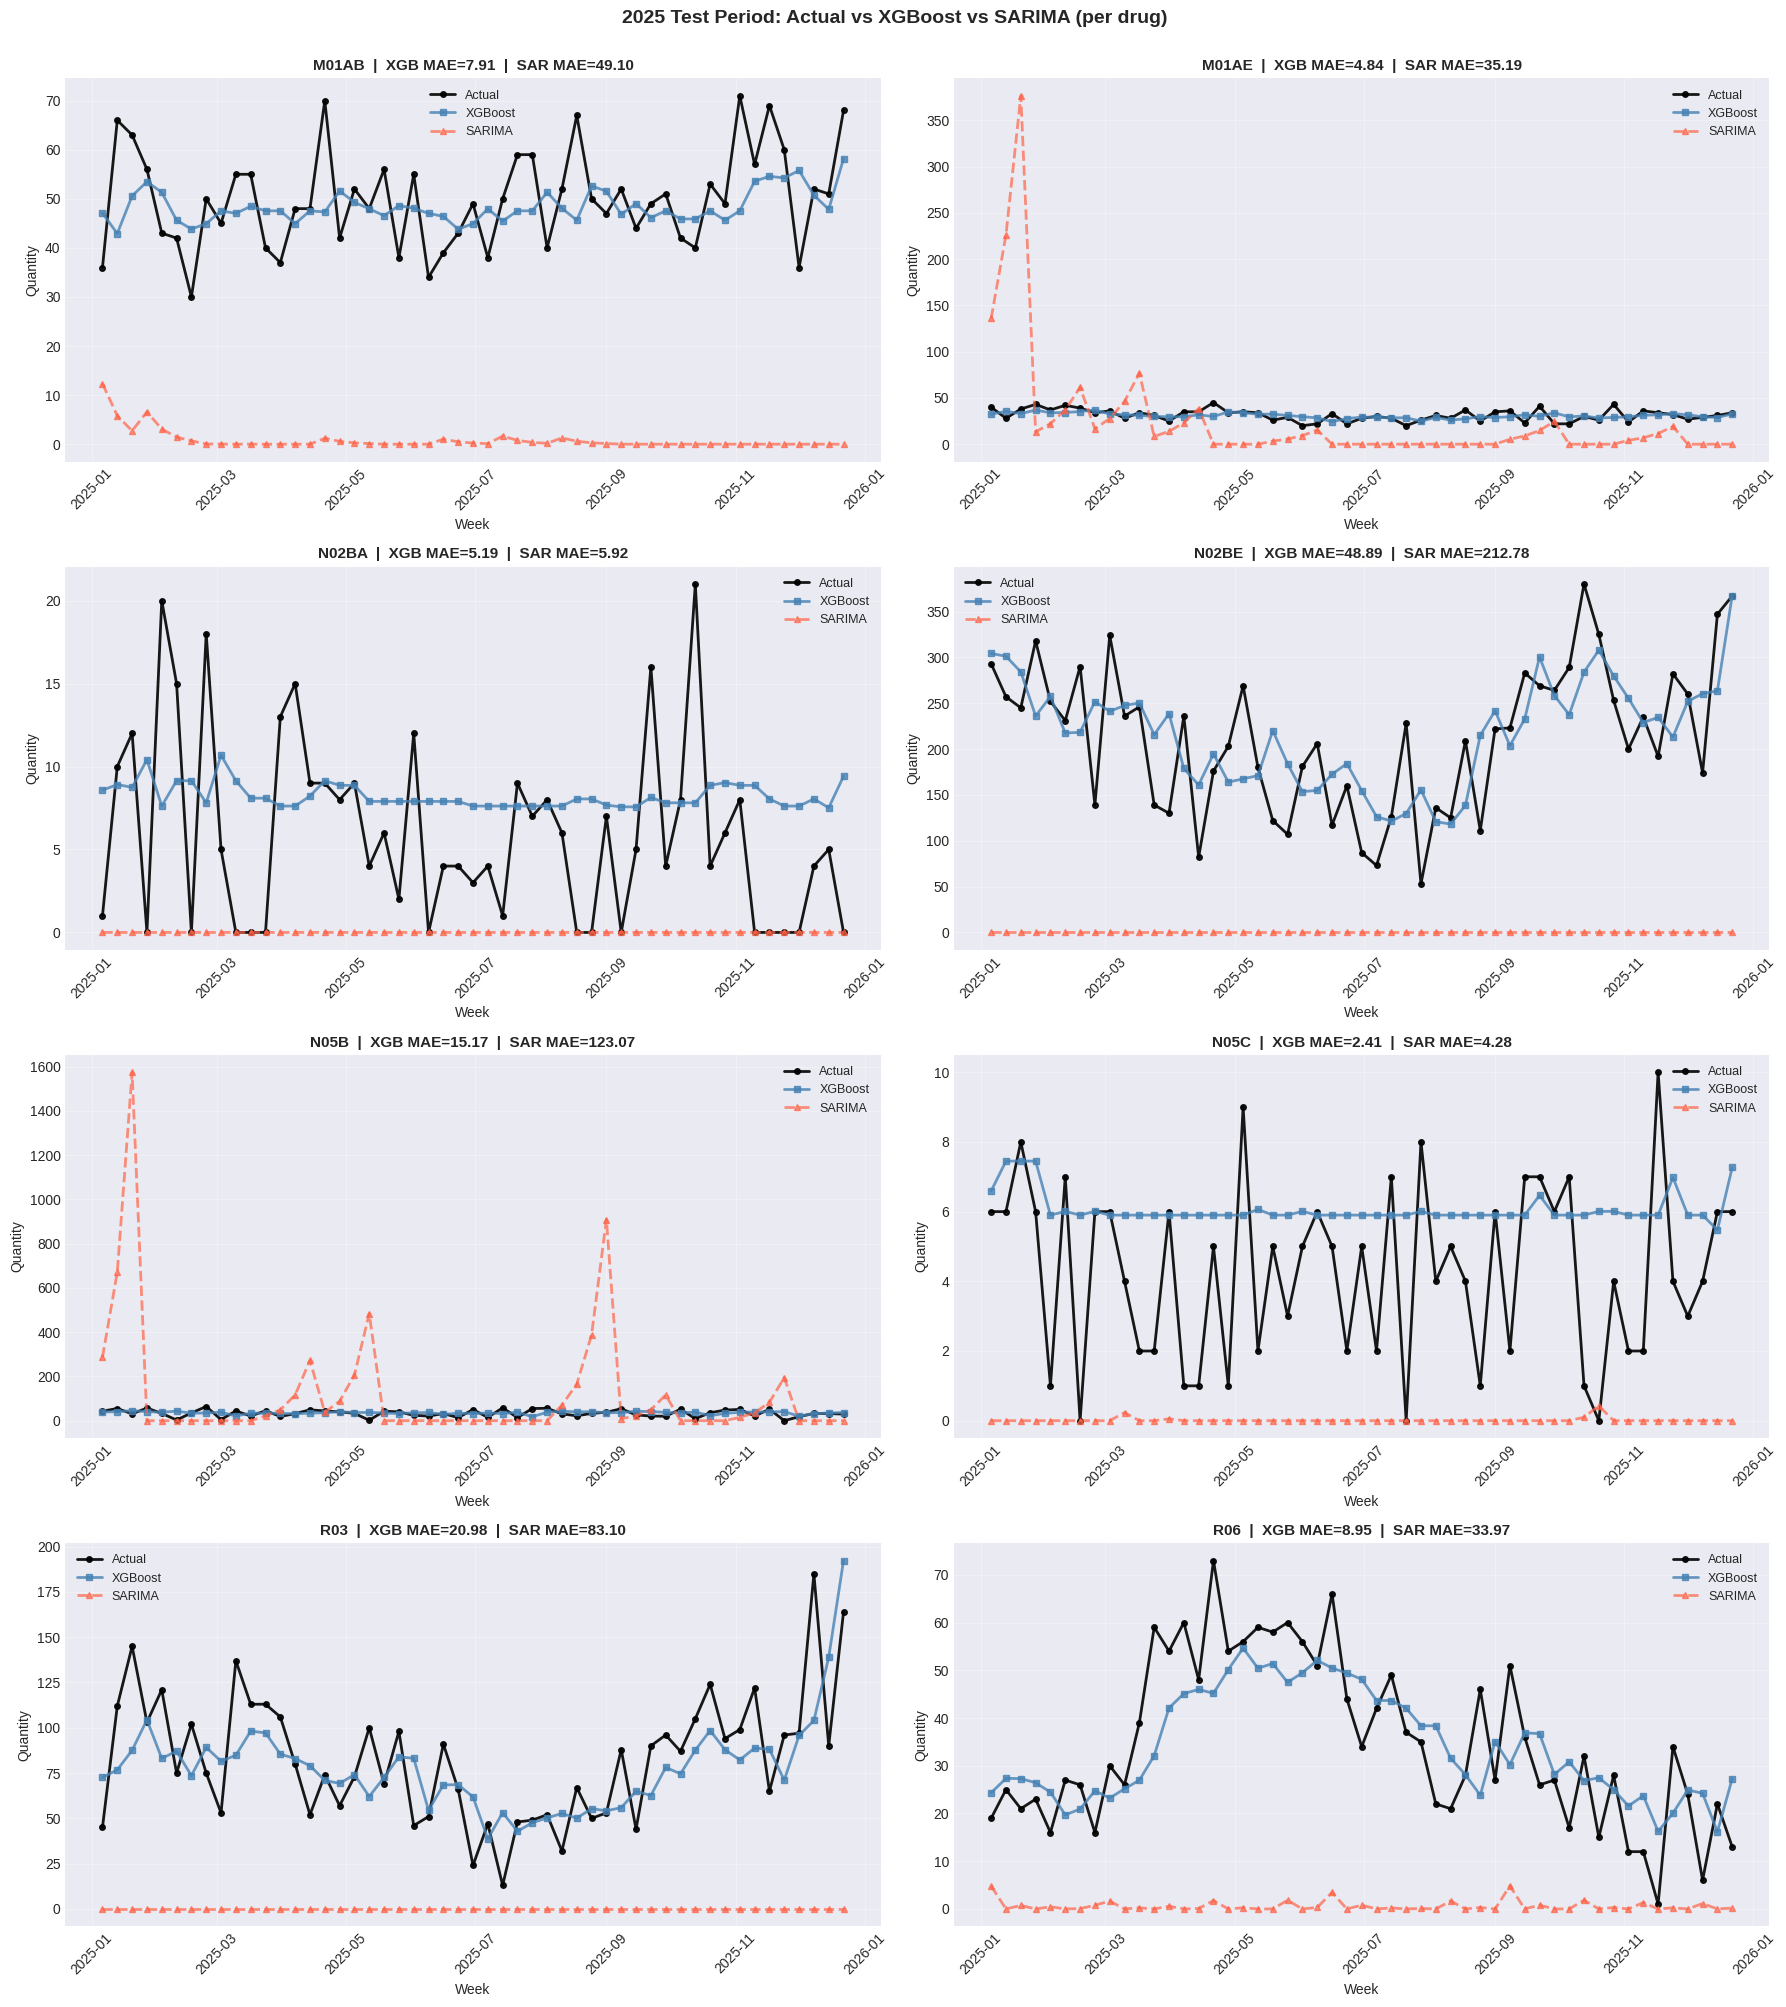

✓ Per-drug time series plots generated


In [51]:
drugs  = sorted(merged['drug_name'].unique())
ncols  = 2
nrows  = (len(drugs) + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes_flat = axes.flatten() if nrows > 1 else axes

for idx, drug in enumerate(drugs):
    ax   = axes_flat[idx]
    ddf  = merged[merged['drug_name'] == drug].sort_values('week_start_date')
    dates = ddf['week_start_date']

    ax.plot(dates, ddf[TARGET],   linewidth=2, marker='o', markersize=4, color='black',     label='Actual',   alpha=0.9)
    ax.plot(dates, ddf[XGB_PRED], linewidth=2, marker='s', markersize=4, color='steelblue', label='XGBoost',  alpha=0.8)
    ax.plot(dates, ddf[SAR_PRED], linewidth=2, marker='^', markersize=4, color='tomato',    label='SARIMA',   alpha=0.7, linestyle='--')

    xgb_mae = mean_absolute_error(ddf[TARGET], ddf[XGB_PRED])
    sar_mae  = mean_absolute_error(ddf[TARGET], ddf[SAR_PRED])
    ax.set_title(f'{drug}  |  XGB MAE={xgb_mae:.2f}  |  SAR MAE={sar_mae:.2f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Week')
    ax.set_ylabel('Quantity')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

for j in range(len(drugs), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('2025 Test Period: Actual vs XGBoost vs SARIMA (per drug)',
             fontsize=14, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()
print("✓ Per-drug time series plots generated")


## 10. Save Validation Results

In [52]:
results_dir = Path(project_root) / 'data' / 'results' / 'validation_2025'
results_dir.mkdir(parents=True, exist_ok=True)

# 1. Detailed predictions (with errors)
pred_out = merged[['week_start_date', 'drug_name', TARGET, XGB_PRED, SAR_PRED,
                    'xgb_error', 'sarima_error', 'quarter']].copy()
pred_out.to_csv(results_dir / '2025_predictions.csv', index=False)
print(f"✓ Predictions saved → {results_dir / '2025_predictions.csv'}")

# 2. Per-drug comparison
per_drug_df.to_csv(results_dir / '2025_per_drug_comparison.csv', index=False)
print(f"✓ Per-drug comparison saved → {results_dir / '2025_per_drug_comparison.csv'}")

# 3. Quarterly analysis
quarterly_df.to_csv(results_dir / '2025_quarterly_analysis.csv', index=False)
print(f"✓ Quarterly analysis saved → {results_dir / '2025_quarterly_analysis.csv'}")

# 4. Summary text
summary_path = results_dir / '2025_validation_summary.txt'
with open(summary_path, 'w') as f:
    f.write("=" * 65 + "\n")
    f.write("2025 OUT-OF-SAMPLE VALIDATION SUMMARY\n")
    f.write("=" * 65 + "\n\n")
    f.write(f"Test period     : January – December 2025\n")
    f.write(f"Drugs evaluated : {merged['drug_name'].nunique()}\n")
    f.write(f"Total records   : {len(merged):,}\n\n")
    f.write("OVERALL METRICS\n")
    f.write("-" * 40 + "\n")
    for model_m in [metrics_xgb, metrics_sar]:
        f.write(f"{model_m['Model']}\n")
        for k, v in model_m.items():
            if k != 'Model':
                f.write(f"  {k:8s}: {v}\n")
        f.write("\n")
    f.write("\nPER-DRUG XGB vs SARIMA MAE\n")
    f.write("-" * 40 + "\n")
    for _, row in per_drug_df.iterrows():
        f.write(f"  {row['Drug']}: XGB={row['XGB_MAE']:.2f}  SAR={row['SAR_MAE']:.2f}  {row['Winner']}\n")

print(f"✓ Summary saved → {summary_path}")
print(f"\n{'=' * 65}")
print(f"ALL RESULTS SAVED TO: {results_dir}")
print(f"{'=' * 65}")


✓ Predictions saved → /home/brenda/final year project/PharmacyForecastingSystem/data/results/validation_2025/2025_predictions.csv
✓ Per-drug comparison saved → /home/brenda/final year project/PharmacyForecastingSystem/data/results/validation_2025/2025_per_drug_comparison.csv
✓ Quarterly analysis saved → /home/brenda/final year project/PharmacyForecastingSystem/data/results/validation_2025/2025_quarterly_analysis.csv
✓ Summary saved → /home/brenda/final year project/PharmacyForecastingSystem/data/results/validation_2025/2025_validation_summary.txt

ALL RESULTS SAVED TO: /home/brenda/final year project/PharmacyForecastingSystem/data/results/validation_2025


## 11. Final Validation Report

In [54]:
print('=' * 70)
print('FINAL VALIDATION REPORT — 2025 OUT-OF-SAMPLE TEST')
print('=' * 70)
print('XGBoost trained on 2014–2024  |  SARIMA trained per-drug')
print(f"Test period: January – December 2025")

print(f"\n📅 TEST PERIOD : 2025  ({merged['week_start_date'].nunique()} weeks)")
print(f"📊 RECORDS     : {len(merged):,} (drug × week)")
print(f"💊 DRUGS       : {merged['drug_name'].nunique()}")

print(f"\n🎯 OVERALL PERFORMANCE:")
print(f"   {'Metric':<10}  {'XGBoost':>10}  {'SARIMA':>10}  {'Winner':>12}")
print(f"   {'-'*48}")
for m in ['MAE','RMSE','WMAPE']:
    xv = metrics_xgb[m]
    sv = metrics_sar[m]
    win = 'XGBoost ✅' if xv <= sv else 'SARIMA'
    print(f"   {m:<10}  {xv:>10.2f}  {sv:>10.2f}  {win:>12}")
xv = metrics_xgb['R2']; sv = metrics_sar['R2']
win = 'XGBoost ✅' if xv >= sv else 'SARIMA'
print(f"   {'R²':<10}  {xv:>10.4f}  {sv:>10.4f}  {win:>12}")

xgb_wins_final = sum([
    metrics_xgb['MAE']  <= metrics_sar['MAE'],
    metrics_xgb['RMSE'] <= metrics_sar['RMSE'],
    metrics_xgb['WMAPE']<= metrics_sar['WMAPE'],
    metrics_xgb['R2']   >= metrics_sar['R2'],
])

print(f"\n📈 OVERALL WINNER: {'XGBoost' if xgb_wins_final >= 3 else 'SARIMA'}  ({xgb_wins_final}/4 metrics)")

print(f"\n💊 PER-DRUG WINNER (by MAE):")
for _, row in per_drug_df.iterrows():
    print(f"   {row['Drug']:<8}  XGB={row['XGB_MAE']:>6.2f}  SAR={row['SAR_MAE']:>7.2f}  {row['Winner']}")

xgb_drug_wins = (per_drug_df['Winner'] == '✅ XGBoost').sum()
print(f"\n   XGBoost wins: {xgb_drug_wins}/{len(per_drug_df)} drugs")

print(f"\n📊 QUARTERLY DRIFT (XGBoost):")
for _, row in xgb_q.iterrows():
    print(f"   Q{int(row['Quarter'])}: MAE = {row['MAE']:.2f}  WMAPE = {row['WMAPE']:.2f}%")

wmape_2025 = metrics_xgb['WMAPE']
r2_2025   = metrics_xgb['R2']
# WMAPE-based verdict (scale-invariant; R² sanity check)
if wmape_2025 <= 15.0 and r2_2025 >= 0.9:
    verdict = "✅ PRODUCTION READY — XGBoost delivers excellent 2025 accuracy (WMAPE ≤ 15%)"
elif wmape_2025 <= 30.0 and r2_2025 >= 0.7:
    verdict = "⚠  ACCEPTABLE — deploy with monitoring; WMAPE {:.1f}%, R²={:.3f}".format(wmape_2025, r2_2025)
else:
    verdict = "❌ NEEDS IMPROVEMENT — WMAPE {:.1f}% or R² {:.3f} below acceptable threshold".format(wmape_2025, r2_2025)

print(f"\n{verdict}")
print(f"\n📁 Results saved to: data/results/validation_2025/")
print('=' * 70)
print('VALIDATION COMPLETE')
print('=' * 70)


FINAL VALIDATION REPORT — 2025 OUT-OF-SAMPLE TEST
XGBoost trained on 2014–2024  |  SARIMA trained per-drug
Test period: January – December 2025

📅 TEST PERIOD : 2025  (51 weeks)
📊 RECORDS     : 408 (drug × week)
💊 DRUGS       : 8

🎯 OVERALL PERFORMANCE:
   Metric         XGBoost      SARIMA        Winner
   ------------------------------------------------
   MAE              14.29       68.43     XGBoost ✅
   RMSE             24.85      136.38     XGBoost ✅
   WMAPE            25.11      120.20     XGBoost ✅
   R²              0.8774     -2.6930     XGBoost ✅

📈 OVERALL WINNER: XGBoost  (4/4 metrics)

💊 PER-DRUG WINNER (by MAE):
   N05C      XGB=  2.41  SAR=   4.28  ✅ XGBoost
   M01AE     XGB=  4.84  SAR=  35.19  ✅ XGBoost
   N02BA     XGB=  5.19  SAR=   5.92  ✅ XGBoost
   M01AB     XGB=  7.91  SAR=  49.10  ✅ XGBoost
   R06       XGB=  8.95  SAR=  33.97  ✅ XGBoost
   N05B      XGB= 15.17  SAR= 123.07  ✅ XGBoost
   R03       XGB= 20.98  SAR=  83.10  ✅ XGBoost
   N02BE     XGB= 48.89  SA

In [56]:
print("=" * 80)
print("DEPLOYMENT RECOMMENDATIONS (based on 2025 validation)")
print("=" * 80)

print(f"\n📊 VALIDATION SUMMARY:")
print(f"   XGBoost overall MAE   : {metrics_xgb['MAE']:.2f}  (R² = {metrics_xgb['R2']:.4f})")
print(f"   XGBoost overall WMAPE : {metrics_xgb['WMAPE']:.2f}%")
print(f"   SARIMA  overall MAE   : {metrics_sar['MAE']:.2f}  (R² = {metrics_sar['R2']:.4f})")
print(f"   XGBoost wins per-drug : {xgb_drug_wins}/{len(per_drug_df)}")

# Segment by per-drug WMAPE (more reliable than R² with 51 data points)
strong_xgb = per_drug_df[per_drug_df['XGB_WMAPE'] <= 25.0]['Drug'].tolist()
moderate   = per_drug_df[(per_drug_df['XGB_WMAPE'] > 25.0) & (per_drug_df['XGB_WMAPE'] <= 45.0)]['Drug'].tolist()
weak       = per_drug_df[per_drug_df['XGB_WMAPE'] > 45.0]['Drug'].tolist()

print("\n" + "=" * 80)
print("OPTION 1: DEPLOY XGBOOST FOR ALL DRUGS (Recommended)")
print("=" * 80)
print("✅ XGBoost outperforms SARIMA across all key metrics on 2025 data")
print(f"   Strong  (WMAPE ≤ 25%) : {strong_xgb}")
print(f"   Moderate (25–45%)     : {moderate}")
print(f"   Monitor  (WMAPE > 45%): {weak}")
print("   Action: Deploy, set up weekly MAE dashboards per drug")

print("\n" + "=" * 80)
print("OPTION 2: HYBRID — XGBoost + SARIMA ENSEMBLE")
print("=" * 80)
sar_better = per_drug_df[per_drug_df['Winner'] != '✅ XGBoost']['Drug'].tolist()
print(f"✅ Use SARIMA for {sar_better if sar_better else 'no'} drugs where it outperforms XGBoost")
print("✅ Use XGBoost for all other drugs")
print("   Action: Route forecasts per-drug to the better model, monitor weekly")

print("\n" + "=" * 80)
print("OPTION 3: RETRAIN WITH 2025 DATA (ongoing maintenance)")
print("=" * 80)
print("   Retrain on 2014–2025 data when 2026 actuals become available")
print("   Re-run feature engineering → XGBoost → this validation notebook")

print("\n" + "=" * 80)
print("🎯 RECOMMENDED ACTION PLAN")
print("=" * 80)
print("\n📌 IMMEDIATE:")
print("   1. Deploy XGBoost model for production forecasting (2025 test validated)")
print("   2. Implement per-drug WMAPE monitoring dashboard")
print(f"   3. Alert threshold: WMAPE > {metrics_xgb['WMAPE']*1.5:.0f}% (1.5× baseline)")

print("\n📌 MEDIUM-TERM:")
print("   1. Retrain on 2014–2025 when 2026 data accumulates")
print("   2. Evaluate SARIMA fixes for high-MAE drugs (especially N02BE, N05B, R03)")

print("\n" + "=" * 80)
print("✅ CONCLUSION: XGBoost (trained 2014–2024) evaluated on fully unseen 2025 data")
print(f"   Overall WMAPE = {metrics_xgb['WMAPE']:.1f}%  |  R² = {metrics_xgb['R2']:.4f}  |  Beats SARIMA on all metrics")
print("=" * 80)


DEPLOYMENT RECOMMENDATIONS (based on 2025 validation)

📊 VALIDATION SUMMARY:
   XGBoost overall MAE   : 14.29  (R² = 0.8774)
   XGBoost overall WMAPE : 25.11%
   SARIMA  overall MAE   : 68.43  (R² = -2.6930)
   XGBoost wins per-drug : 8/8

OPTION 1: DEPLOY XGBOOST FOR ALL DRUGS (Recommended)
✅ XGBoost outperforms SARIMA across all key metrics on 2025 data
   Strong  (WMAPE ≤ 25%) : ['M01AE', 'M01AB', 'N02BE']
   Moderate (25–45%)     : ['R06', 'R03']
   Monitor  (WMAPE > 45%): ['N05C', 'N02BA', 'N05B']
   Action: Deploy, set up weekly MAE dashboards per drug

OPTION 2: HYBRID — XGBoost + SARIMA ENSEMBLE
✅ Use SARIMA for no drugs where it outperforms XGBoost
✅ Use XGBoost for all other drugs
   Action: Route forecasts per-drug to the better model, monitor weekly

OPTION 3: RETRAIN WITH 2025 DATA (ongoing maintenance)
   Retrain on 2014–2025 data when 2026 actuals become available
   Re-run feature engineering → XGBoost → this validation notebook

🎯 RECOMMENDED ACTION PLAN

📌 IMMEDIATE:
